# Data Loading and Initial QC

This notebook prepares the breast cancer transcriptomics dataset for downstream analysis. The workflow follows six steps:

1. locate and load the raw expression matrix,
2. inspect its structure and missing values,
3. simplify the labels to a binary classification problem,
4. confirm that the feature matrix is numeric,
5. inspect the expression value distribution,
6. export the cleaned feature matrix and target labels.

The raw file used here is `Breast_GSE45827.csv`, which is loaded into `df`.

In [2]:
# Imports
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Determine project root path (Kernel is at notebooks/ level)
project_root = Path.cwd()
if not (project_root / "data").exists():
    project_root = project_root.parent

# Get data path
data_path = str(project_root) + "/data"

## Step 1: Inspect the raw matrix

Before transforming the dataset, we verify the basic structure of the imported table: its dimensions, the first columns, the distribution of sample types, and whether any values are missing. This confirms that the file was read correctly and shows how much cleaning is needed before modeling.

In [5]:
# Load Data
df = pd.read_csv(data_path + "/raw/Breast_GSE45827.csv")
df.head()

,samples,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,84,basal,9.850040,8.097927,6.424728,7.353027,3.029122,6.880079,4.963740,4.408328,...,12.229711,11.852955,13.658701,13.477698,6.265781,5.016196,4.901594,2.966657,3.508495,3.301999
1,85,basal,9.861357,8.212222,7.062593,7.685578,3.149468,7.542283,5.129607,4.584418,...,12.178531,11.809408,13.750086,13.470146,6.771853,5.291005,5.405839,2.934763,3.687666,3.064299
2,87,basal,10.103478,8.936137,5.735970,7.687822,3.125931,6.562369,4.813449,4.425195,...,12.125108,11.725766,13.621732,13.295080,6.346952,5.171403,5.184286,2.847684,3.550597,3.158535
3,90,basal,9.756875,7.357148,6.479183,6.986624,3.181638,7.802344,5.490982,4.567956,...,12.111235,11.719215,13.743108,13.508861,6.610284,5.193356,5.086569,3.031602,3.524981,3.272665
4,91,basal,9.408330,7.746404,6.693980,7.333426,3.169923,7.610457,5.372469,4.424426,...,12.173642,11.861296,13.797774,13.542206,6.414354,5.040202,5.235318,2.956232,3.445501,3.193947


In [44]:
print("CSV matrix format: ", df.shape)
print("First 10 columns : ",df.columns[:10])
print(df['type'].value_counts())
print("Number of empty cells : ", df.isnull().sum().sum())

CSV matrix format:  (137, 54678)
First 10 columns :  Index(['samples', 'type', '1007_s_at', '1053_at', '117_at', '121_at',
       '1255_g_at', '1294_at', '1316_at', '1320_at'],
      dtype='object')
type
basal        41
HER          30
luminal_B    30
luminal_A    29
normal        7
Name: count, dtype: int64
Number of empty cells :  0


## Step 2: Define the prediction labels

The original metadata contains several sample categories. For most of this project, we reduce the task to a binary classification problem: `normal` versus `tumor`.

To keep the comparison biologically consistent, samples labeled `cell_line` are removed first. These are in vitro models and can have transcriptional profiles that differ substantially from primary tissue samples. After filtering, we create a new `label` column that maps samples to the two classes used in the rest of the analysis.

In [35]:
# remove cell lines
df = df[df['type'] != 'cell_line']

df['label'] = df['type'].apply(lambda x: 'normal' if x == 'normal' else 'tumor')
df['label'].value_counts()

label
tumor     130
normal      7
Name: count, dtype: int64

In [36]:
# reshape data
df['label'] = df['type'].apply(lambda x: 'normal' if x == 'normal' else 'tumor')

## Step 3: Split features and target

Once the labels are defined, we separate the dataset into:

- `X`: the gene expression matrix only,
- `y`: the target vector containing the binary labels.

Columns that describe sample identity or metadata are excluded from `X` so that only numeric gene-level predictors remain.

In [37]:
# genes
X = df.drop(columns=['samples', 'type', 'label'])

# labels
y = df['label']

## Step 4: Confirm the feature matrix is numeric

Machine learning models expect numerical inputs. This check verifies that all columns in `X` have numeric types and that no metadata columns were accidentally left in the expression matrix.

In [38]:
X.dtypes.value_counts()

float64    54675
Name: count, dtype: int64

## Step 5: Review expression value distribution

Before applying any additional preprocessing, we inspect summary statistics and the global value distribution. The goal is to assess whether the expression values already look normalized and log-transformed, which would affect whether further scaling or transformation is appropriate.

In [ ]:
X.describe().T[['mean','std']].head()


,mean,std
1007_s_at,10.383256,0.552752
1053_at,7.511681,0.605101
117_at,6.320796,0.591805
121_at,7.314202,0.300052
1255_g_at,3.179723,0.159637


In [40]:
print("Min value : ", X.values.min())
print("Max value : ", X.values.max())

Min value :  2.17109972663613
Max value :  14.9701002149474


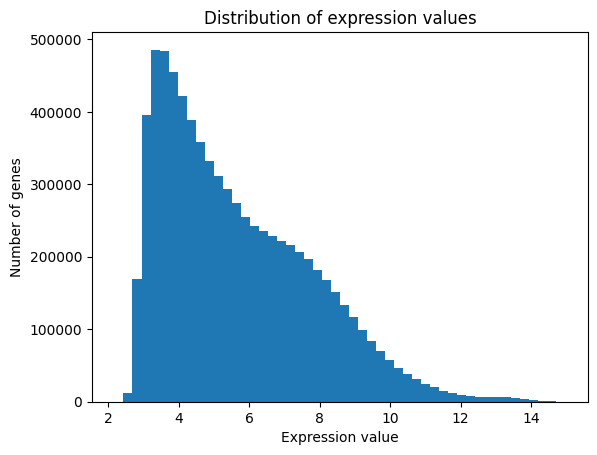

In [41]:
plt.hist(X.values.flatten(), bins=50)
plt.title("Distribution of expression values")
plt.ylabel("Number of genes")
plt.xlabel("Expression value")
plt.show()

## Interpretation of the QC checks

The observed expression range is relatively compact, and the summary statistics do not suggest raw count-scale values. Together with the histogram, this supports the interpretation that the dataset has already been normalized and likely log-transformed. Based on this inspection, no additional transformation is applied in this notebook.

## Step 6: Export the cleaned dataset

After filtering the sample types, creating the binary labels, and validating the structure of the expression matrix, we save the processed outputs for reuse in later notebooks:

- `X_clean.csv` for the cleaned feature matrix,
- `y_clean.csv` for the target labels.

In [46]:
X.to_csv(data_path + "/processed/X_clean.csv", index=False)
y.to_csv(data_path + "/processed/y_clean.csv", index=False)